<a href="https://colab.research.google.com/github/djoseph06/Heart-Disease-Classifier/blob/main/Heart_Disease_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q ucimlrepo


In [3]:
from ucimlrepo import fetch_ucirepo

heart = fetch_ucirepo(id=45)

X = heart.data.features.copy()
target = heart.data.targets.copy()

display(X.head())
display(target.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


In [4]:
y = (target["num"] > 0).astype(int)

print(y.value_counts().rename(index={0: "No disease", 1: "Disease present"}))


num
No disease         164
Disease present    139
Name: count, dtype: int64


In [5]:
print(X.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training patients:", len(X_train))
print("Test patients:", len(X_test))


Training patients: 242
Test patients: 61


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_columns = [
    "sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"
]

numeric_steps = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

categorical_steps = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_steps, numeric_columns),
    ("categorical", categorical_steps, categorical_columns)
])

logistic_model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

print("Logistic regression trained!")


Logistic regression trained!


Accuracy: 88.5%
              precision    recall  f1-score   support

  No disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



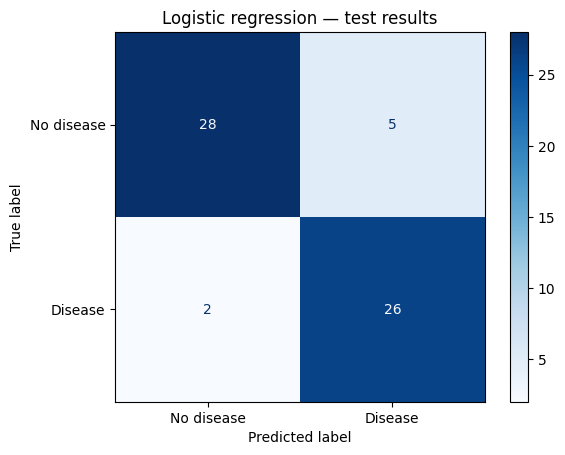

In [9]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred = logistic_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.1%}")

print(classification_report(
    y_test,
    y_pred,
    target_names=["No disease", "Disease"],
    zero_division=0
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No disease", "Disease"],
    cmap="Blues"
)
plt.title("Logistic regression — test results")
plt.show()

In [11]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier

forest_model = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

forest_model.fit(X_train, y_train)

print("Random forest trained!")

Random forest trained!


In [13]:
forest_pred = forest_model.predict(X_test)

print(f"Random forest accuracy: {accuracy_score(y_test, forest_pred):.1%}")

print(classification_report(
    y_test,
    forest_pred,
    target_names=["No disease", "Disease"],
    zero_division=0
))


Random forest accuracy: 85.2%
              precision    recall  f1-score   support

  No disease       0.90      0.82      0.86        33
     Disease       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



In [14]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in [
    ("Logistic regression", logistic_model),
    ("Random forest", forest_model)
]:
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "disease_recall": "recall",
            "roc_auc": "roc_auc"
        }
    )

    results.append({
        "Model": name,
        "Mean accuracy": scores["test_accuracy"].mean(),
        "Accuracy std": scores["test_accuracy"].std(),
        "Mean disease recall": scores["test_disease_recall"].mean(),
        "Mean ROC-AUC": scores["test_roc_auc"].mean()
    })

comparison = pd.DataFrame(results).set_index("Model")
display(comparison.round(3))

,Mean accuracy,Accuracy std,Mean disease recall,Mean ROC-AUC
Model,,,,
Logistic regression,0.847,0.010,0.783,0.902
Random forest,0.814,0.027,0.774,0.893


Logistic Regression had the higher average accuracy as well as a better consistent accuracy

In [16]:

sample_patient = X_test.iloc[[1]]

prediction = logistic_model.predict(sample_patient)[0]
probability = logistic_model.predict_proba(sample_patient)[0, 1]

labels = {0: "No disease", 1: "Disease present"}

display(sample_patient)

print("Predicted class:", labels[prediction])
print(f"Model-estimated probability of disease presence: {probability:.1%}")
print("Actual dataset label:", labels[y_test.iloc[1]])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
271,66,1,4,160,228,0,2,138,0,2.3,1,0.0,6.0


Predicted class: Disease present
Model-estimated probability of disease presence: 60.1%
Actual dataset label: No disease


In [17]:
import pandas as pd

predictions = logistic_model.predict(X_test)
probabilities = logistic_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Actual label": y_test.to_numpy(),
    "Predicted label": predictions,
    "Disease probability (%)": (probabilities * 100).round(1)
}, index=X_test.index)

results["Correct"] = (
    results["Actual label"] == results["Predicted label"]
)

display(results.head(10))

,Actual label,Predicted label,Disease probability (%),Correct
219,0,0,20.9,True
271,0,1,60.1,False
89,0,0,2.1,True
101,0,0,3.3,True
67,0,0,31.2,True
244,0,0,1.6,True
185,0,0,11.7,True
233,0,0,34.9,True
168,1,1,72.2,True
197,0,0,34.7,True


In [18]:
display(results[results["Correct"] == False])

,Actual label,Predicted label,Disease probability (%),Correct
271,0,1,60.1,False
196,0,1,69.3,False
33,0,1,72.8,False
287,0,1,53.2,False
66,1,0,26.7,False
92,0,1,85.7,False
172,1,0,43.8,False


These are the false positives
